# Hicieron crecer un intestino humano de 8 centímetros. En 10 semanas.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Y no es solo un tubo de células. Es un intestino con su propio sistema nervioso entérico — el que controla la contracción, late solo, responde a fármacos. Hasta hoy, para llegar a eso había que ensamblarlo a mano juntando piezas. El equipo encontró un atajo: **encerrarlo**.

**Paper**: *Large-scale and innervated functional human gut tissues for transplantation via transient spheroid confinement*
**Revista**: Nature Biomedical Engineering, 2026
**DOI**: [10.1038/s41551-026-01688-6](https://doi.org/10.1038/s41551-026-01688-6)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-22-organoides-intestino-funcional-ens/notebook.ipynb)


## El problema que estaban resolviendo

Los organoides de intestino existen desde hace años, pero les faltaba algo crítico: **nervios**. Sin sistema nervioso entérico (la red que controla la peristalsis), el tejido no se contrae bien, no responde a señales, no madura del todo. La solución estándar — los *assembloides* — exige cultivar nervios por separado y luego pegarlos al tejido. Lento, frágil, difícil de escalar.

El equipo probó otra ruta: imprimieron en 3D una bandeja que **confina** los esferoides mientras crecen. Esa restricción física es la que hace todo lo demás — el tamaño, los nervios, la maduración. Probaron la idea en tres órganos distintos: intestino delgado, colon y estómago.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_CCS = '#2563EB'       # Sistema nuevo (Confined Culture System)
COLOR_HIO = '#999999'       # Método tradicional (organoides clásicos)
COLOR_ALERTA = '#DC2626'    # TTX, intervención farmacológica
COLOR_REFERENCIA = '#D97706'
COLOR_EXTRA = '#059669'     # L-NAME (sintasa de óxido nítrico bloqueada)
FUENTE = 'Fuente: Park et al. (2026), Nature Biomedical Engineering — DOI: 10.1038/s41551-026-01688-6'

import os, urllib.request, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# Carga de datasets
fig1f = pd.read_csv('datos/fig1f_graft_size_intestino_delgado.csv')
fig5c = pd.read_csv('datos/fig5c_graft_size_colon.csv')
fig5f = pd.read_csv('datos/fig5f_graft_size_estomago.csv')
fig3b = pd.read_csv('datos/fig3b_amplitud_contractil.csv')
fig3f = pd.read_csv('datos/fig3f_ttx_si_ccs.csv')
fig3g = pd.read_csv('datos/fig3g_farmacologia_si_ccs.csv')
fig6j = pd.read_csv('datos/fig6j_fitc_flux_barrera.csv')
crypt = pd.read_csv('datos/ext_data_1j_crypt_depth.csv')
villus = pd.read_csv('datos/ext_data_1k_villus_height.csv')
muscle = pd.read_csv('datos/ext_data_1l_muscle_thickness.csv')

print(f'Intestino delgado (Fig 1f): n_HIO={len(fig1f[fig1f.tipo=="HIO"])}, n_SI_CCS={len(fig1f[fig1f.tipo=="SI CCS"])}')
print(f'Colon (Fig 5c):              n_HCO={len(fig5c[fig5c.tipo=="HCO"])}, n_C_CCS={len(fig5c[fig5c.tipo=="C CCS"])}')
print(f'Estómago (Fig 5f):           n_HaGO={len(fig5f[fig5f.tipo=="HaGO"])}, n_G_CCS={len(fig5f[fig5f.tipo=="G CCS"])}')
print(f'TTX pareado (Fig 3f):        n={len(fig3f[fig3f.condicion=="control"])} (mismas muestras antes/después)')
print(f'Farmacología (Fig 3g):       n={len(fig3g[fig3g.condicion=="control"])} por condición')
print(f'Barrera FITC (Fig 6j):       n_sham={len(fig6j[fig6j.condicion=="SI CCS Sham"])}, n_tie_in={len(fig6j[fig6j.condicion=="SI CCS Tie In"])}')


Intestino delgado (Fig 1f): n_HIO=6, n_SI_CCS=9
Colon (Fig 5c):              n_HCO=5, n_C_CCS=6
Estómago (Fig 5f):           n_HaGO=6, n_G_CCS=5
TTX pareado (Fig 3f):        n=8 (mismas muestras antes/después)
Farmacología (Fig 3g):       n=8 por condición
Barrera FITC (Fig 6j):       n_sham=3, n_tie_in=4


## Aquí está el salto.

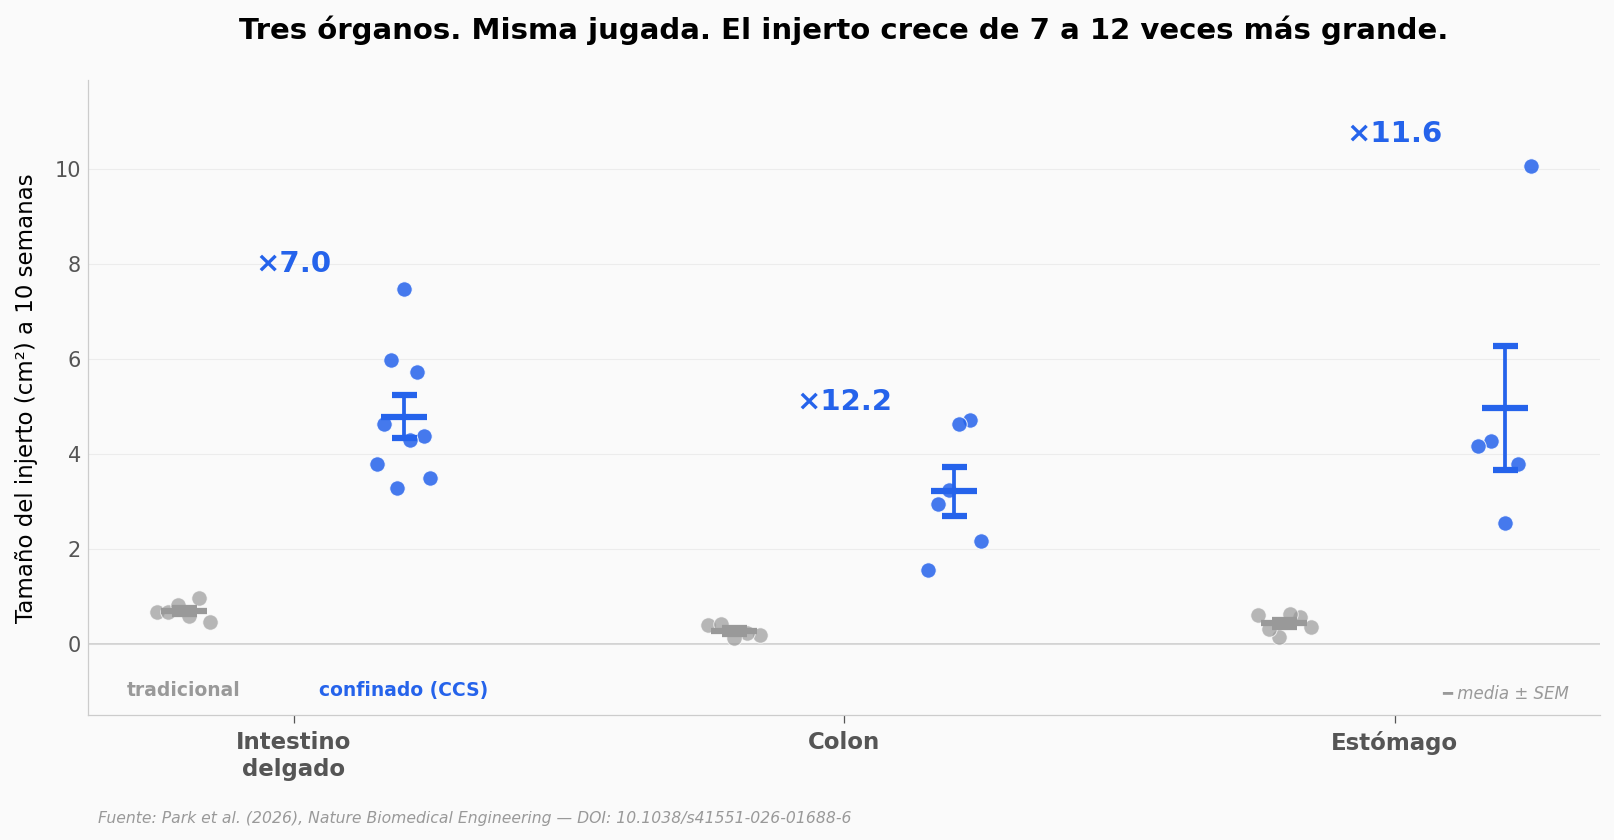

In [2]:
# Gráfica hero — fold-change de tamaño en los tres órganos
fig, ax = plt.subplots(figsize=(13, 5.5))

np.random.seed(42)

datos = [
    ('Intestino\ndelgado', fig1f[fig1f.tipo == 'HIO']['tamano_cm2'].values,
                            fig1f[fig1f.tipo == 'SI CCS']['tamano_cm2'].values),
    ('Colon',                fig5c[fig5c.tipo == 'HCO']['tamano_cm2'].values,
                            fig5c[fig5c.tipo == 'C CCS']['tamano_cm2'].values),
    ('Estómago',             fig5f[fig5f.tipo == 'HaGO']['tamano_cm2'].values,
                            fig5f[fig5f.tipo == 'G CCS']['tamano_cm2'].values),
]

positions_clasico = [0, 2.5, 5]
positions_nuevo   = [1, 3.5, 6]

for i, (organo, clasico, nuevo) in enumerate(datos):
    # Método clásico (HIO/HCO/HaGO)
    x_strip = np.linspace(positions_clasico[i] - 0.12, positions_clasico[i] + 0.12, len(clasico))
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, clasico, color=COLOR_HIO, s=55, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    m_c = clasico.mean(); sem_c = clasico.std(ddof=1) / np.sqrt(len(clasico))
    ax.errorbar(positions_clasico[i], m_c, yerr=sem_c, fmt='_', color=COLOR_HIO,
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

    # Sistema nuevo (CCS)
    x_strip = np.linspace(positions_nuevo[i] - 0.12, positions_nuevo[i] + 0.12, len(nuevo))
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, nuevo, color=COLOR_CCS, s=55, alpha=0.85,
               edgecolors='white', linewidths=0.5, zorder=5)
    m_n = nuevo.mean(); sem_n = nuevo.std(ddof=1) / np.sqrt(len(nuevo))
    ax.errorbar(positions_nuevo[i], m_n, yerr=sem_n, fmt='_', color=COLOR_CCS,
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

    # Anotación del fold-change
    fold = m_n / m_c
    ax.annotate(f'×{fold:.1f}',
                xy=((positions_clasico[i] + positions_nuevo[i]) / 2, max(nuevo.max(), m_n) * 1.05),
                fontsize=14, fontweight='bold', color=COLOR_CCS, ha='center')

ax.set_xticks([(a + b) / 2 for a, b in zip(positions_clasico, positions_nuevo)])
ax.set_xticklabels([d[0] for d in datos], fontsize=11, fontweight='bold')

# Etiquetas inline de método (sobre eje horizontal)
ax.text(positions_clasico[0], -1.1, 'tradicional', fontsize=9, color=COLOR_HIO,
        ha='center', fontweight='bold')
ax.text(positions_nuevo[0],   -1.1, 'confinado (CCS)', fontsize=9, color=COLOR_CCS,
        ha='center', fontweight='bold')

ax.set_ylabel('Tamaño del injerto (cm²) a 10 semanas', fontsize=11)
ax.set_title('Tres órganos. Misma jugada. El injerto crece de 7 a 12 veces más grande.',
             fontsize=14, fontweight='bold', pad=20)

ax.set_ylim(-1.5, max([d[2].max() for d in datos]) * 1.18)
ax.axhline(y=0, color='#cccccc', linewidth=0.8, zorder=1)

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_tres_organos.png', dpi=200, bbox_inches='tight')
plt.show()


### Lo que dicen los datos

El paper había anunciado *up to 10×*. Calculando con los puntos individuales del Source Data:

- **Intestino delgado**: 7× más grande — de ~0.7 a ~4.8 cm² (n = 6 vs 9, p = 0.0004, d = 3.8). El más conservador.
- **Colon**: 12× más grande — de ~0.3 a ~3.2 cm² (n = 5 vs 6, p = 0.004, d = 3.1).
- **Estómago**: 12× más grande — de ~0.4 a ~5 cm² (n = 6 vs 5, p = 0.004, d = 2.3).

*Todos los p-values son Mann-Whitney de dos colas; d es Cohen's d.*

El "10×" del abstract es un buen promedio, pero esconde que los dos órganos donde el método empuja más fuerte son colon y estómago. El intestino delgado ya partía de injertos relativamente grandes con el método clásico — había menos margen.

Lo que ningún número del paper captura es la dispersión. Los puntos azules abren en abanico: hay organoides que llegaron a 7 o 10 cm². La heterogeneidad es real y honesta — no todos los confinamientos producen el mismo tejido.


## ¿Y por dentro? Mismo tejido, más maduro

Que el injerto sea más grande no garantiza que sea mejor tejido. La pregunta de fondo: ¿la anatomía microscópica se ve también desarrollada? El equipo midió tres variables del intestino delgado a 10 semanas:

- Profundidad de criptas: **+41%** (d = 5.0, p = 0.029)
- Altura de vellosidades: **+33%** (d = 2.6, p = 0.029)
- Grosor del músculo liso: **+50%** (d = 4.1, p = 0.029)

Todos n = 4 vs 4, Mann-Whitney de dos colas.


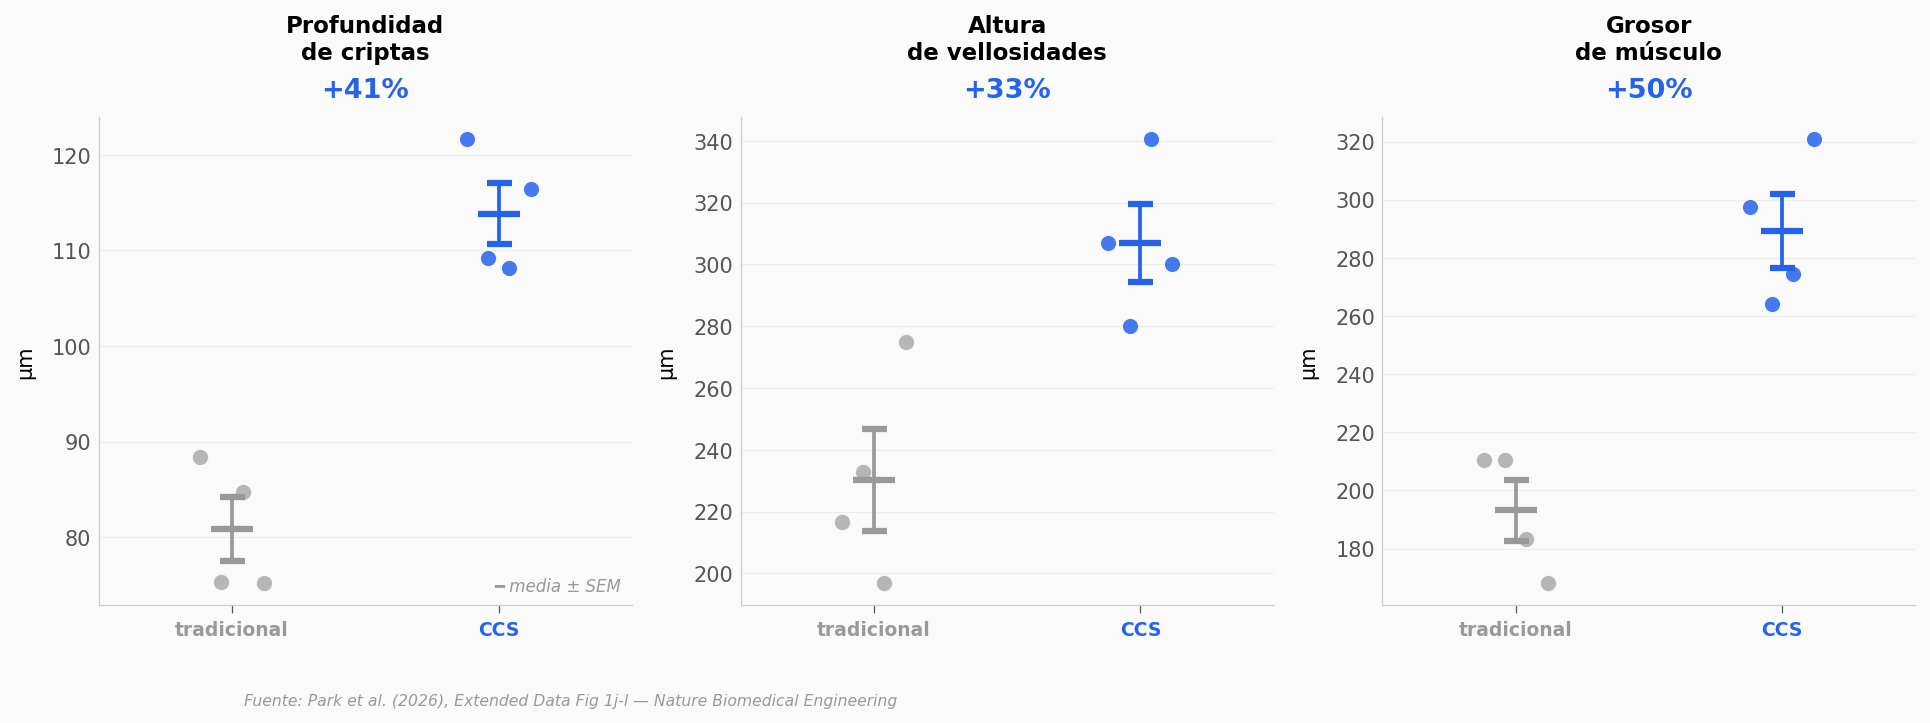

In [3]:
# Subplot triple: anatomía microscópica del intestino delgado
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

variables = [
    (crypt,  'profundidad_um', 'Profundidad\nde criptas', axes[0]),
    (villus, 'altura_um',      'Altura\nde vellosidades', axes[1]),
    (muscle, 'grosor_um',      'Grosor\nde músculo',      axes[2]),
]

np.random.seed(42)
for df, col, titulo, ax in variables:
    hio = df[df.tipo == 'HIO'][col].values
    ccs = df[df.tipo == 'SI CCS'][col].values

    x_h = np.linspace(-0.12, 0.12, len(hio)); np.random.shuffle(x_h)
    x_c = np.linspace(0.88, 1.12, len(ccs)); np.random.shuffle(x_c)

    ax.scatter(x_h, hio, color=COLOR_HIO, s=60, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)
    ax.scatter(x_c, ccs, color=COLOR_CCS, s=60, alpha=0.85,
               edgecolors='white', linewidths=0.5, zorder=5)

    for pos, vals, color in [(0, hio, COLOR_HIO), (1, ccs, COLOR_CCS)]:
        m = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(len(vals))
        ax.errorbar(pos, m, yerr=sem, fmt='_', color=color,
                    markersize=20, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

    cambio_pct = (ccs.mean() - hio.mean()) / hio.mean() * 100
    ax.text(0.5, 1.04, f'+{cambio_pct:.0f}%',
            transform=ax.transAxes, fontsize=13, fontweight='bold',
            color=COLOR_CCS, ha='center')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['tradicional', 'CCS'], fontsize=9, fontweight='bold')
    ax.get_xticklabels()[0].set_color(COLOR_HIO)
    ax.get_xticklabels()[1].set_color(COLOR_CCS)
    ax.set_title(titulo, fontsize=11, pad=28)
    ax.set_ylabel('µm', fontsize=10)
    ax.set_xlim(-0.5, 1.5)

axes[0].text(0.98, 0.02, '━ media ± SEM',
             transform=axes[0].transAxes, fontsize=8, color='#999999',
             ha='right', va='bottom', style='italic')

plt.tight_layout()
fig.text(0.13, -0.06,
         'Fuente: Park et al. (2026), Extended Data Fig 1j-l — Nature Biomedical Engineering',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anatomia_microscopica.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Y los nervios funcionan?

Crecer más grande es una cosa. Tener un sistema nervioso entérico que de verdad **funciona** es otra. La prueba real: si inyectas fármacos que apagan nervios específicos, ¿el tejido deja de responder?

Tres experimentos farmacológicos en serie:

- **TTX (tetrodotoxina)** bloquea los canales de sodio dependientes de voltaje — apaga toda transmisión nerviosa
- **L-NAME** inhibe la enzima que produce óxido nítrico (NO) — apaga solo los nervios inhibitorios nitrérgicos
- **L-NAME + atropina** añade el bloqueo colinérgico — quita también los nervios excitatorios

Si los datos cuadran, esa secuencia debe leerse así: TTX apaga todo, L-NAME sube la actividad (porque quita el freno inhibitorio), y atropina sobre L-NAME apaga lo que quedaba.


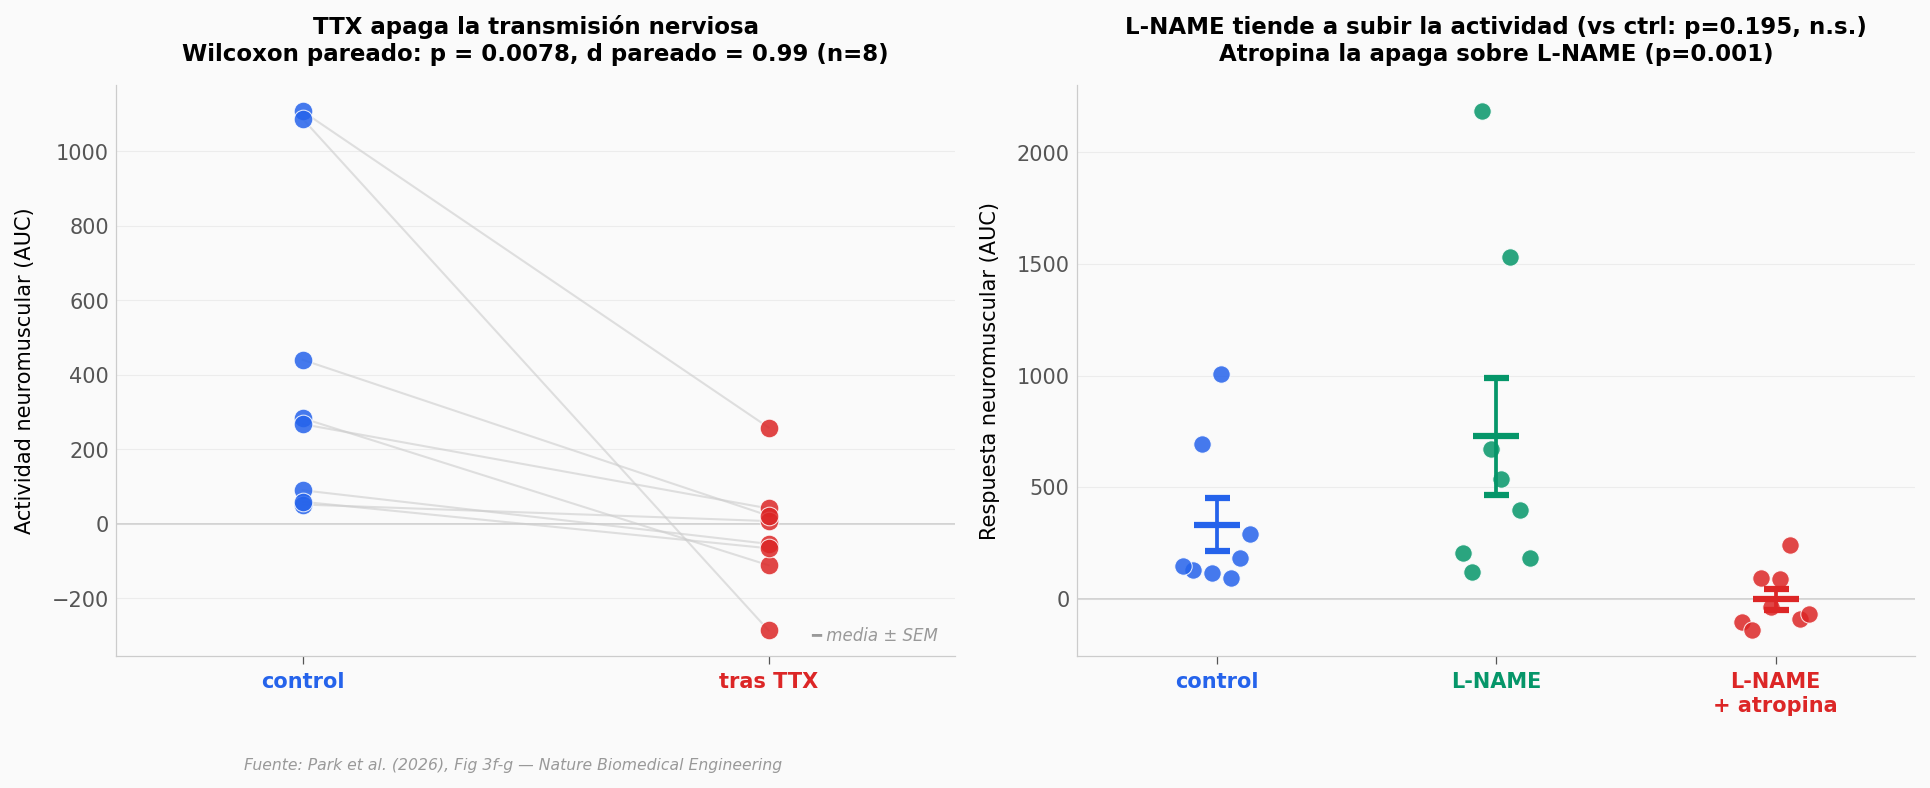

In [4]:
# Pharmacología — dos paneles: TTX pareado + L-NAME/atropina
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# === Panel A: TTX pareado ===
ax = axes[0]
control = fig3f[fig3f.condicion == 'control']['auc_neuromuscular'].values
ttx     = fig3f[fig3f.condicion == 'after ttx']['auc_neuromuscular'].values
n = len(control)

# Líneas pareadas (cada muestra: control → after_TTX)
for c, t in zip(control, ttx):
    ax.plot([0, 1], [c, t], color='#cccccc', linewidth=1, alpha=0.6, zorder=2)

ax.scatter([0]*n, control, color=COLOR_CCS, s=80, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)
ax.scatter([1]*n, ttx, color=COLOR_ALERTA, s=80, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)

# Test Wilcoxon pareado
w_stat, p_w = stats.wilcoxon(control, ttx)

ax.axhline(y=0, color='#cccccc', linewidth=0.8, zorder=1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['control', 'tras TTX'], fontsize=10, fontweight='bold')
ax.get_xticklabels()[0].set_color(COLOR_CCS)
ax.get_xticklabels()[1].set_color(COLOR_ALERTA)
ax.set_ylabel('Actividad neuromuscular (AUC)', fontsize=10)
ax.set_xlim(-0.4, 1.4)
diff = control - ttx; d_paired = diff.mean() / diff.std(ddof=1)
ax.set_title(f'TTX apaga la transmisión nerviosa\nWilcoxon pareado: p = {p_w:.4f}, d pareado = {d_paired:.2f} (n={n})',
             fontsize=11, pad=12)

# === Panel B: L-NAME y atropina ===
ax = axes[1]
ctrl  = fig3g[fig3g.condicion == 'control']['respuesta'].values
ln    = fig3g[fig3g.condicion == 'lname']['respuesta'].values
ln_a  = fig3g[fig3g.condicion == 'lname+atropine']['respuesta'].values
n_g = len(ctrl)

np.random.seed(42)
for i, (vals, color, pos, label) in enumerate([
    (ctrl, COLOR_CCS, 0, 'control'),
    (ln, COLOR_EXTRA, 1, 'L-NAME'),
    (ln_a, COLOR_ALERTA, 2, 'L-NAME\n+ atropina'),
]):
    x_strip = np.linspace(pos - 0.12, pos + 0.12, len(vals)); np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=70, alpha=0.85,
               edgecolors='white', linewidths=0.5, zorder=5)
    m = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(pos, m, yerr=sem, fmt='_', color=color,
                markersize=22, markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

ax.axhline(y=0, color='#cccccc', linewidth=0.8, zorder=1)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['control', 'L-NAME', 'L-NAME\n+ atropina'], fontsize=10, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_CCS, COLOR_EXTRA, COLOR_ALERTA]):
    tick.set_color(color)
ax.set_ylabel('Respuesta neuromuscular (AUC)', fontsize=10)
ax.set_xlim(-0.5, 2.5)
u1,p1 = stats.mannwhitneyu(ctrl, ln, alternative='two-sided'); u2,p2 = stats.mannwhitneyu(ln, ln_a, alternative='two-sided')
ax.set_title(f'L-NAME tiende a subir la actividad (vs ctrl: p={p1:.3f}, n.s.)\nAtropina la apaga sobre L-NAME (p={p2:.3f})',
             fontsize=11, pad=12)

axes[0].text(0.98, 0.02, '━ media ± SEM',
             transform=axes[0].transAxes, fontsize=8, color='#999999',
             ha='right', va='bottom', style='italic')

plt.tight_layout()
fig.text(0.13, -0.04,
         'Fuente: Park et al. (2026), Fig 3f-g — Nature Biomedical Engineering',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/farmacologia.png', dpi=200, bbox_inches='tight')
plt.show()


## La barrera. ¿Aguanta tras el transplante?

Un tejido grande con nervios funcionales no sirve de nada si, al conectarlo al lumen del huésped, se vuelve permeable. La barrera intestinal es la primera línea de defensa frente a bacterias, toxinas y antígenos del propio contenido digestivo. Si se rompe, el animal se enferma.

El equipo midió el flujo de FITC-dextrán (un trazador fluorescente) a través de la pared del injerto, comparando organoides en posición *sham* (sin conectar al lumen) con organoides en posición *tie-in* (conectados al tracto digestivo de la rata).


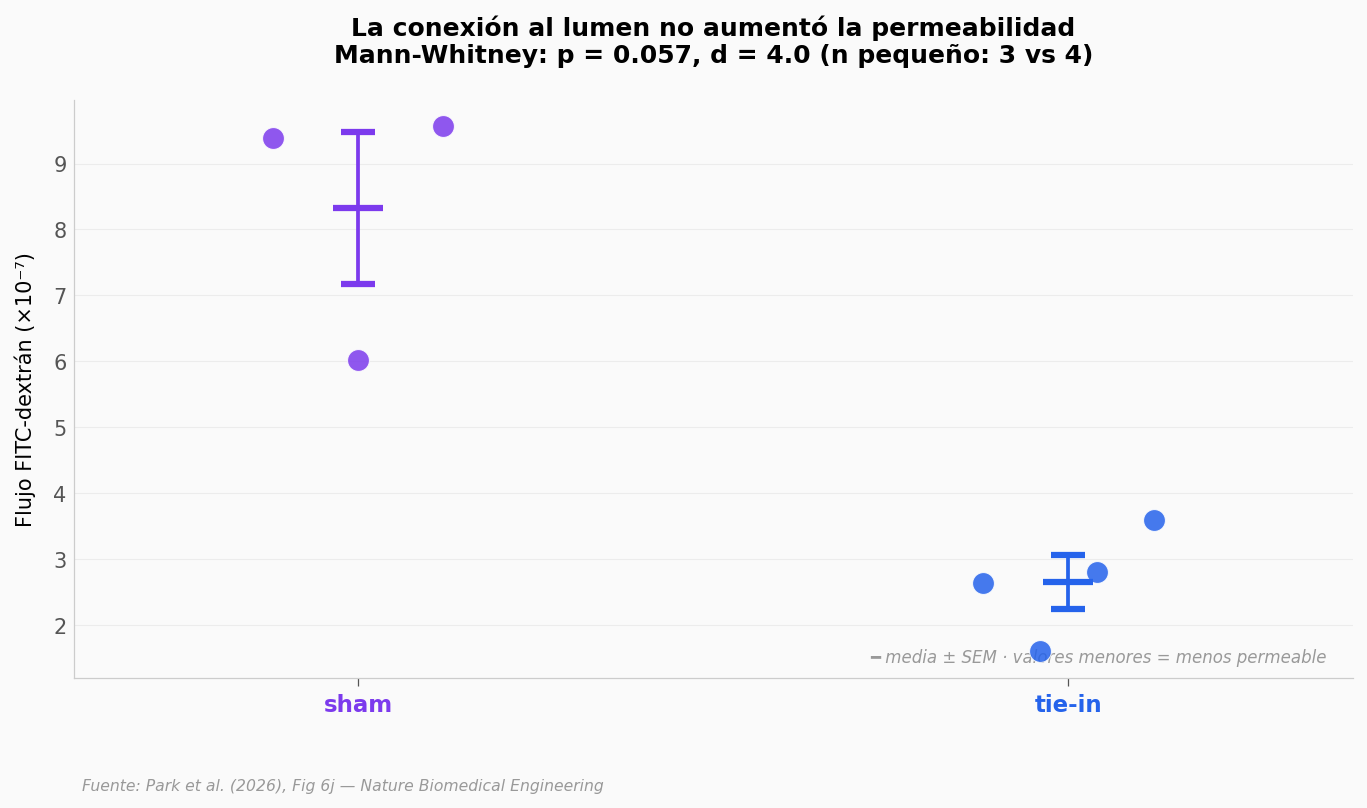

Media sham   = 8.33 × 10⁻⁷
Media tie-in = 2.66 × 10⁻⁷
p-value Mann-Whitney = 0.0571


In [5]:
# Barrera FITC: sham vs tie-in
fig, ax = plt.subplots(figsize=(11, 5))

sham   = fig6j[fig6j.condicion == 'SI CCS Sham']['fitc_flux'].values * 1e7
tie_in = fig6j[fig6j.condicion == 'SI CCS Tie In']['fitc_flux'].values * 1e7
n_sham = len(sham); n_tie = len(tie_in)

# Test Mann-Whitney (n pequeño, no asumir normalidad)
u_stat, p_mw = stats.mannwhitneyu(sham, tie_in, alternative='two-sided')

np.random.seed(42)
x_s = np.linspace(-0.12, 0.12, n_sham); np.random.shuffle(x_s)
x_t = np.linspace(0.88, 1.12, n_tie); np.random.shuffle(x_t)

ax.scatter(x_s, sham, color='#7C3AED', s=110, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5, label='sham (sin conexión)')
ax.scatter(x_t, tie_in, color=COLOR_CCS, s=110, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5, label='tie-in (conectado al lumen)')

for pos, vals, color in [(0, sham, '#7C3AED'), (1, tie_in, COLOR_CCS)]:
    m = vals.mean(); sem = vals.std(ddof=1) / np.sqrt(len(vals))
    ax.errorbar(pos, m, yerr=sem, fmt='_', color=color,
                markersize=24, markeredgewidth=3, capsize=8, capthick=1.5, zorder=6)

ax.set_xticks([0, 1])
ax.set_xticklabels(['sham', 'tie-in'], fontsize=11, fontweight='bold')
ax.get_xticklabels()[0].set_color('#7C3AED')
ax.get_xticklabels()[1].set_color(COLOR_CCS)
ax.set_ylabel('Flujo FITC-dextrán (×10⁻⁷)', fontsize=10)
ax.set_xlim(-0.4, 1.4)
pooled = np.sqrt(((n_sham-1)*sham.var(ddof=1)+(n_tie-1)*tie_in.var(ddof=1))/(n_sham+n_tie-2)); d = (sham.mean()-tie_in.mean())/pooled
ax.set_title(f'La conexión al lumen no aumentó la permeabilidad\n'
             f'Mann-Whitney: p = {p_mw:.3f}, d = {d:.1f} (n pequeño: {n_sham} vs {n_tie})',
             fontsize=12, fontweight='bold', pad=18)

ax.text(0.98, 0.02, '━ media ± SEM · valores menores = menos permeable',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.04,
         'Fuente: Park et al. (2026), Fig 6j — Nature Biomedical Engineering',
         fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/barrera_fitc.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Media sham   = {sham.mean():.2f} × 10⁻⁷')
print(f'Media tie-in = {tie_in.mean():.2f} × 10⁻⁷')
print(f'p-value Mann-Whitney = {p_mw:.4f}')


## Ahora tú

Tres preguntas para abrir los datos:

**1. ¿Cuál de los tres órganos tiene la dispersión más alta dentro del grupo CCS?**
Pista: calcula el coeficiente de variación (`std / mean`) para `fig1f`, `fig5c`, `fig5f` solo en el grupo nuevo.

**2. ¿Cuán grande es el efecto de TTX comparado con la variabilidad pre-TTX?**
Pista: el Cohen's d pareado se calcula como `media_diferencias / std_diferencias`. Compáralo con lo que dice el paper.

**3. ¿La diferencia anatómica más fuerte (crypt, villus, muscle) es la misma que el paper destaca?**
Pista: calcula el cambio relativo en cada una y ordénalas.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: coeficiente de variación del grupo CCS por órgano

for nombre, df, tipo_ccs in [
    ('Intestino delgado', fig1f, 'SI CCS'),
    ('Colon', fig5c, 'C CCS'),
    ('Estómago', fig5f, 'G CCS'),
]:
    vals = df[df.tipo == tipo_ccs]['tamano_cm2'].values
    cv = vals.std(ddof=1) / vals.mean()
    print(f'{nombre:20s} CCS · n={len(vals):2d} · media={vals.mean():.2f} cm² · CV={cv:.2f}')

print()
print('El órgano con más dispersión es el que tiene el CV más alto.')
print('Eso te dice cuánto varía entre experimentos — no todos los confinamientos producen lo mismo.')


Intestino delgado    CCS · n= 9 · media=4.78 cm² · CV=0.29
Colon                CCS · n= 6 · media=3.20 cm² · CV=0.40
Estómago             CCS · n= 5 · media=4.96 cm² · CV=0.59

El órgano con más dispersión es el que tiene el CV más alto.
Eso te dice cuánto varía entre experimentos — no todos los confinamientos producen lo mismo.


## Fuentes

**Paper**: [Large-scale and innervated functional human gut tissues for transplantation via transient spheroid confinement](https://doi.org/10.1038/s41551-026-01688-6)  
*Nature Biomedical Engineering, 2026-05-22*

**Supplementary Material**: [Source Data — Park et al. 2026](https://www.nature.com/articles/s41551-026-01688-6#Sec24)  
*Mismo DOI · contiene los CSVs reanalizados en este notebook*

*15 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia datos**: Source Data publicado bajo Creative Commons (Nature Biomedical Engineering).
**Licencia notebook**: MIT.
**Repositorio**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
